# AirNow and CAM-chem SE (unstructured grid)

Here we show a quick example of how to compare unstructured grid model output to surface observations. Note that the sample file provided here shouldn't be used for scientific analysis. For scientific applications, the community MUSICAv0 CONUS simulates are available at https://doi.org/10.5065/tgbj-yv18. 

First we need to import the driver.

In [1]:
from melodies_monet import driver

## Initiate the analysis class

Now lets create an instance of the {mod}`melodies_monet.driver` {class}`~melodies_monet.driver.analysis` class.
It consists of 4 main parts: model instances, observation instances, a paired instance of both.
This will allow us to move things around the plotting function for spatial and overlays and more complex plots.

In [2]:
an = driver.analysis()
an

analysis(
    control='control.yaml',
    control_dict=None,
    models={},
    obs={},
    paired={},
    start_time=None,
    end_time=None,
    time_intervals=None,
    download_maps=True,
    output_dir=None,
    output_dir_save=None,
    output_dir_read=None,
    debug=False,
    save=None,
    read=None,
    regrid=False,
)

## Control File

Read in the required yaml control file that sets up all the definitions of what we want to pair and plot.

In [3]:
#an.control = 'control_camchem_se.yaml'
an.control = '/glade/u/home/lcthompson/mm/MELODIES-MONET/docs/examples/ungridded_support/control_airnow_cesm-fv_20240801.yaml'
an.read_control()
an.control_dict

{'analysis': {'start_time': '2023-01-01',
  'end_time': '2023-02-01',
  'output_dir': '/glade/u/home/lcthompson/mm/MELODIES-MONET/docs/examples/ungridded_support/output',
  'output_dir_save': '/glade/u/home/lcthompson/mm/MELODIES-MONET/docs/examples/ungridded_support/output',
  'output_dir_read': '/glade/u/home/lcthompson/mm/MELODIES-MONET/docs/examples/ungridded_support/output',
  'save': {'paired': {'method': 'netcdf',
    'prefix': '20230101',
    'data': 'all'}},
  'read': {'paired': {'method': 'netcdf',
    'filenames': {'airnow_cesm_fv': ['airnow_cesm_fv']}}},
  'download_maps': False,
  'debug': False},
 'model': {'cesm_fv': {'files': ['/glade/campaign/acom/acom-weather/emmons/ASIAAQ_sims/f.e3b08.FHISTC_LTt1s.camsm11_finn26.2023.merra2.ne30.01/atm/hist/f.e3b08.FHISTC_LTt1s.camsm11_finn26.2023.merra2.ne30.01.cam.h2a.2023-01-01-82800.nc'],
   'mod_type': 'cesm_fv',
   'radius_of_influence': 110000,
   'mapping': {'airnow': {'O3': 'OZONE'}},
   'projection': None,
   'plot_kwargs':

## Load the model data 

The driver will automatically loop through the "models" found in the model section of the control file and create model classes for each. Classes include the label, mapping information, and xarray object as well as the filenames.  Note it can open multiple files easily by including wildcards. Here we are only opening one CAM-chem file.

In [4]:
an.open_models()

cesm_fv
['/glade/campaign/acom/acom-weather/emmons/ASIAAQ_sims/f.e3b08.FHISTC_LTt1s.camsm11_finn26.2023.merra2.ne30.01/atm/hist/f.e3b08.FHISTC_LTt1s.camsm11_finn26.2023.merra2.ne30.01.cam.h2a.2023-01-01-82800.nc']
**** Reading CESM FV model output...


In [5]:
an.models

{'cesm_fv': model(
     model='cesm_fv',
     is_global=False,
     radius_of_influence=110000,
     mod_kwargs={'var_list': ['O3']},
     file_str=['/glade/campaign/acom/acom-weather/emmons/ASIAAQ_sims/f.e3b08.FHISTC_LTt1s.camsm11_finn26.2023.merra2.ne30.01/atm/hist/f.e3b08.FHISTC_LTt1s.camsm11_finn26.2023.merra2.ne30.01.cam.h2a.2023-01-01-82800.nc'],
     label='cesm_fv',
     obj=...,
     extra_calc=None,
     mapping={'airnow': {'O3': 'OZONE'}},
     variable_dict=None,
     label='cesm_fv',
     ...
 )}

In [6]:
an.models['cesm_fv'].obj #cesm_fv

<xarray.Dataset> Size: 386MB
Dimensions:    (time: 30, z: 58, y: 192, x: 288)
Coordinates:
  * lev        (z) float64 464B 997.5 991.2 983.2 974.5 ... 9.087 5.445 3.018
  * time       (time) object 240B 2023-01-01 11:30:00 ... 2023-01-29 06:30:00
    longitude  (y, x) float64 442kB -180.0 -178.8 -177.5 ... 176.2 177.5 178.8
    latitude   (y, x) float64 442kB -90.0 -90.0 -90.0 -90.0 ... 90.0 90.0 90.0
Dimensions without coordinates: z, y, x
Data variables:
    O3         (time, z, y, x) float32 385MB dask.array<chunksize=(30, 58, 192, 288), meta=np.ndarray>
Attributes:
    interp_type:       bilinear
    interp_outputgri:  equally spaced with poles
    Conventions:       CF-1.0
    source:            CAM
    case:              f.e3b08.FHISTC_LTt1s.camsm11_finn26.2023.merra2.ne30.01
    logname:           emmons
    host:              dec1442
    initial_file:      /glade/campaign/acom/acom-weather/emmons/ic_files/camc...
    topography_file:   /glade/campaign/cesm/cesmdata/inputdata/atm/cam/topo/s...
    model_doi_url:     not_set
    time_period_freq:  hour_23

In [7]:
# All the info in the model class can be called here.
print(an.models['cesm_fv'].label)
print(an.models['cesm_fv'].mapping)

cesm_fv
{'airnow': {'O3': 'OZONE'}}


In [8]:
# All the info in the analysis class can also be called.
print(an.start_time)
print(an.end_time)
print(an.download_maps)

2023-01-01 00:00:00
2023-02-01 00:00:00
True


## Open Obs

Now for monet-analysis we will open preprocessed data in either netcdf icartt or some other format.  We will not be retrieving data like monetio does for some observations (ie aeronet, airnow, etc....).  Instead we will provide utitilies to do this so that users can add more data easily.

Like models we list all obs objects in the yaml file and it will loop through and create driver.observation instances that include the model type, file, objects (i.e. data object) and label  

In [9]:
an.control_dict['obs']

{'airnow': {'use_airnow': True,
  'filename': '/glade/u/home/lcthompson/mm/MELODIES-MONET/docs/examples/ungridded_support/output/airnow_camchemse/AirNow_20230101_20230201.nc',
  'obs_type': 'pt_sfc',
  'variables': {'OZONE': {'unit_scale': 1,
    'unit_scale_method': '*',
    'nan_value': -1.0,
    'ylabel_plot': 'Ozone (ppbv)',
    'vmin_plot': 20.0,
    'vmax_plot': 80.0,
    'vdiff_plot': 5,
    'nlevels_plot': 21}}}}

In [10]:
an.open_obs()

In [11]:
# All the info in the observation class can also be called.

an.obs['airnow'].obj

<xarray.Dataset> Size: 861MB
Dimensions:     (time: 2232, y: 1, x: 2006)
Coordinates:
  * time        (time) datetime64[ns] 18kB 2023-01-01 ... 2023-02-01T00:30:00
    siteid      (x) <U12 96kB ...
    latitude    (x) float64 16kB ...
    longitude   (x) float64 16kB ...
  * x           (x) int64 16kB 0 1 2 3 4 5 6 ... 2000 2001 2002 2003 2004 2005
Dimensions without coordinates: y
Data variables: (12/31)
    BARPR       (time, y, x) float64 36MB ...
    BC          (time, y, x) float64 36MB ...
    CO          (time, y, x) float64 36MB ...
    NH3         (time, y, x) float64 36MB ...
    NO          (time, y, x) float64 36MB ...
    NO2         (time, y, x) float64 36MB ...
    ...          ...
    utcoffset   (y, x) int64 16kB ...
    cmsa_name   (y, x) float64 16kB ...
    msa_code    (y, x) float64 16kB ...
    msa_name    (y, x) <U52 417kB ...
    state_name  (y, x) <U2 16kB ...
    epa_region  (y, x) <U5 40kB ...
Attributes:
    title:         
    format:        NetCDF-4
    date_created:  2026-05-22

## Pair model and obs data

In [12]:
import psutil
import resource

print(resource.getrlimit(resource.RLIMIT_AS))
print(psutil.virtual_memory())

(-1, -1)
svmem(total=804120739840, available=660010852352, percent=17.9, used=144109887488, free=537119948800, active=17828532224, inactive=186761973760, buffers=1069056, cached=141673385984, shared=13000110080, slab=44418195456)


In [13]:
%%time

import pandas as pd
import numpy as np

# cesm_fv files are objects and not datetime64ns

# Convert cftime objects to standard datetime64[ns]
cesm_time = an.models['cesm_fv'].obj['time'].values
cesm_time_converted = pd.to_datetime([str(t) for t in cesm_time])
an.models['cesm_fv'].obj['time'] = cesm_time_converted

# Verify both are now datetime64[ns]
print(an.models['cesm_fv'].obj['time'].dtype)
print(an.obs['airnow'].obj['time'].dtype)

an.pair_data()

datetime64[ns]
datetime64[ns]
1, in pair data
saving pair
CPU times: user 7.8 s, sys: 3.73 s, total: 11.5 s
Wall time: 15.3 s


In [14]:
print(cesm_time_converted)

DatetimeIndex(['2023-01-01 11:30:00', '2023-01-02 10:30:00',
               '2023-01-03 09:30:00', '2023-01-04 08:30:00',
               '2023-01-05 07:30:00', '2023-01-06 06:30:00',
               '2023-01-07 05:30:00', '2023-01-08 04:30:00',
               '2023-01-09 03:30:00', '2023-01-10 02:30:00',
               '2023-01-11 01:30:00', '2023-01-12 00:30:00',
               '2023-01-12 23:30:00', '2023-01-13 22:30:00',
               '2023-01-14 21:30:00', '2023-01-15 20:30:00',
               '2023-01-16 19:30:00', '2023-01-17 18:30:00',
               '2023-01-18 17:30:00', '2023-01-19 16:30:00',
               '2023-01-20 15:30:00', '2023-01-21 14:30:00',
               '2023-01-22 13:30:00', '2023-01-23 12:30:00',
               '2023-01-24 11:30:00', '2023-01-25 10:30:00',
               '2023-01-26 09:30:00', '2023-01-27 08:30:00',
               '2023-01-28 07:30:00', '2023-01-29 06:30:00'],
              dtype='datetime64[ns]', freq=None)


In [15]:
an.paired

{'airnow_cesm_fv': pair(
     type='pt_sfc',
     radius_of_influence=1000000.0,
     obs='airnow',
     model='cesm_fv',
     model_vars=['O3'],
     obs_vars=['OZONE'],
     filename='airnow_cesm_fv.nc',
 )}

In [16]:
an.paired['airnow_cesm_fv'].obj

<xarray.Dataset> Size: 914MB
Dimensions:     (time: 2232, x: 2006)
Coordinates:
  * time        (time) datetime64[ns] 18kB 2023-01-01 ... 2023-02-01T00:30:00
  * x           (x) int64 16kB 0 1 2 3 4 5 6 ... 2000 2001 2002 2003 2004 2005
Data variables: (12/36)
    BARPR       (time, x) float64 36MB -1.0 -1.0 -1.0 -1.0 ... -1.0 -1.0 -1.0
    BC          (time, x) float64 36MB -1.0 -1.0 -1.0 -1.0 ... -1.0 -1.0 -1.0
    CO          (time, x) float64 36MB -1.0 -1.0 -1.0 -1.0 ... -1.0 -1.0 -1.0
    NH3         (time, x) float64 36MB -1.0 -1.0 -1.0 -1.0 ... -1.0 -1.0 -1.0
    NO          (time, x) float64 36MB -1.0 0.1 4.233e-08 0.7 ... -1.0 -1.0 -1.0
    NO2         (time, x) float64 36MB -1.0 1.9 1.5 1.9 ... -1.0 -1.0 -1.0 -1.0
    ...          ...
    cmsa_name   (x) float64 16kB -1.0 -1.0 -1.0 -1.0 ... -1.0 -1.0 -1.0 -1.0
    msa_code    (x) float64 16kB -1.0 -1.0 -1.0 -1.0 ... -1.0 3.306e+04 -1.0
    msa_name    (x) object 16kB '' '' '' '' '' '' ... '' '' '' ' Miami, OK ' ''
    state_name  (x) object 16kB 'CC' 'CC' 'CC' 'CC' 'CC' 'CC' ... '' '' '' '' ''
    epa_region  (x) object 16kB 'CA' 'CA' 'CA' 'CA' 'CA' ... 'R1' '' 'R6' 'DSUZ'
    siteid      (x) object 16kB '000010601' '000020104' ... 'UZB010001'

## Generate plots

Reference std: 9.469612622398676
CPU times: user 7.59 s, sys: 3.77 s, total: 11.4 s
Wall time: 15.8 s


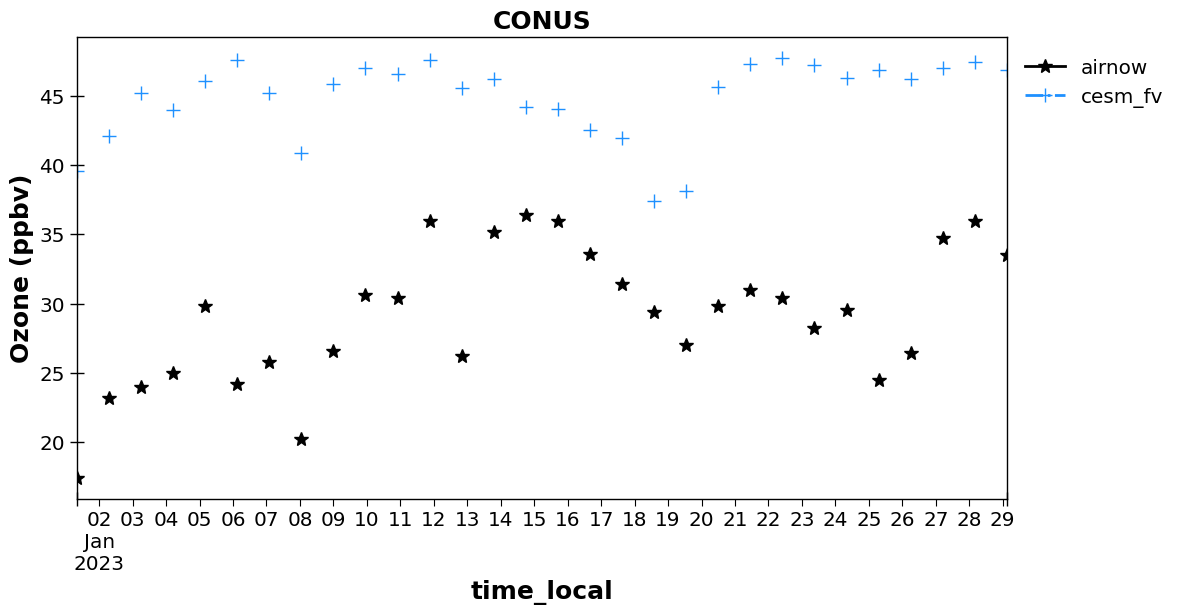

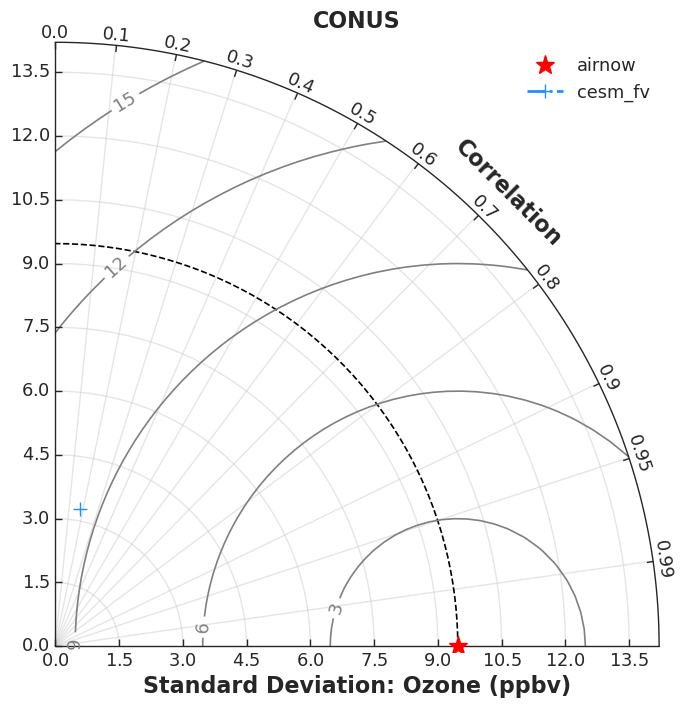

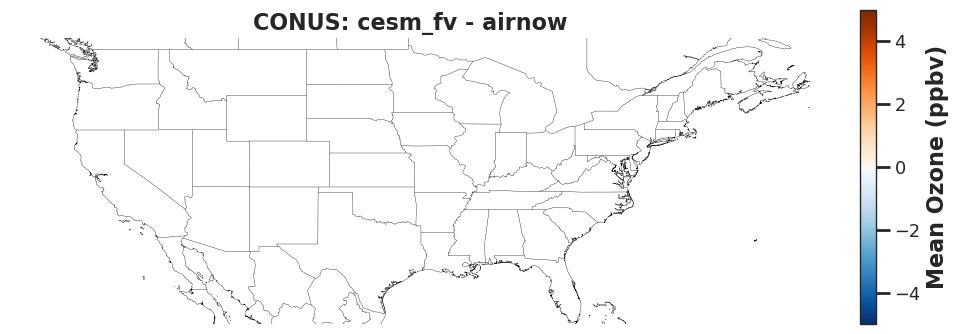

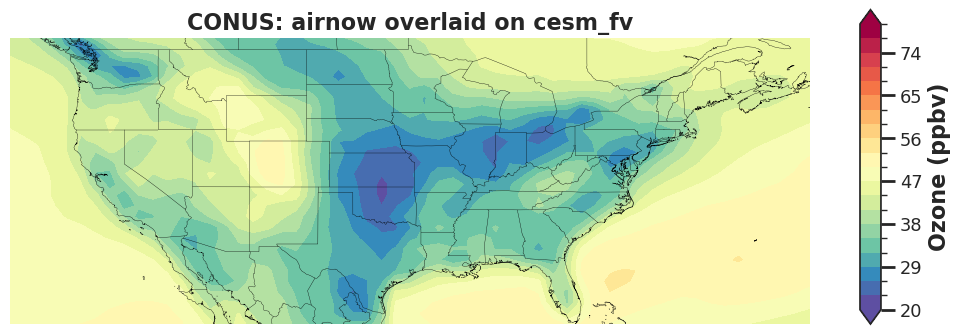

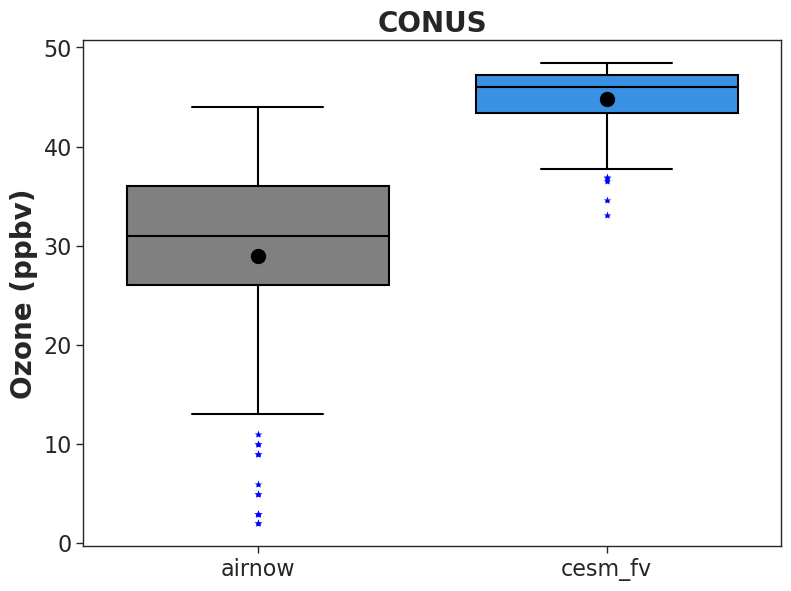

In [17]:
%%time

an.plotting()